<font size=8><center>**Minimum** ***inDecay***  </font>

<center>This notebook aims to reproduce the inDecay with minimum code. Only the most necessary functions and the core building blocks are kept so that you get an idea of how inDecay works. 

## **Sections**

This notebook will cover the following topics:  

1. <font size=3 color='#677e98'>**Reading in SelfTarget data**</font>
    - reference look up dictionary
    - the processed dataframe merging all samples (Oligos)
    - read in the indelgen file
    - `DataSet` and `Dataloader`          
&nbsp;        
2. <font size=3 color='#ceac2d'>**Detecting micro-homology track**</font>
    - alignment map
    - substitution matrix
    - dianogal filter
&nbsp;                
3. <font size=3 color='#618CAC'>**Compiling event features**</font>
    - Detect MH events with substitution matrix and diagnal filter
    - The values of MH and non-MH del events
    - Extract insertion events
    - Feature transformation  
&nbsp;                
4. <font size=3 color='#ceac2d'>**Construct Dataset and Dataloader**</font>
    - `ST_dataset` and `Dataloader`
&nbsp;                
5. <font size=3 color='#a698a1'>**Minimum inDecay model**</font>
    - model architecture
    - Training, evaluation and saving checkpoints
    - Visualization
&nbsp;                
6. <font size=3 color='#a698a1'>**Start training**</font>
    - training with pytorch lightning 
    - predict with the trained model
&nbsp;                
    


## **Prerequisites**

inDecay builds on several packages including
- `inDecay` (brought by this repository) 
- `torch` : All parts of the modelling are structured as a pytorch project. And you can accelerate the training / fine-tuning where GPU is avaiable for you.
- `SelfTarget` : Before modeling, we will use ForeCasT's indelgentarget to generate all possible events.
- `QRguide` : another package of this paper. We highly suggest users or developpers to checkout this package if you wishes to develop new prediction system for CRISPR outcome.

In [68]:
import os, sys
import numpy as np
import pandas as pd
import torch
import inDecay
from Bio import SeqIO
from qrguide import transformation, analysis_fn

# <font size=6 color='#677e98'> **1. Reading data** </font>

In this notebook, we will handle SelfTargeting data from `FORECasT`'s dataset. The dataset is used to pre-train inDecay model in our manuscript. In `FORECasT`'s multi cell-line dataset, each sample is indexed with an unique OligoID (`OligoXXXX`). Each OligoID basically matches a pair of guideRNA-target sequence. 

After downloading the processed SelfTarget dataset (check 👉 [here](https://github.com/StatBiomed/inDecay/blob/main/scripts/Data_download.sh) if you haven't done so), we will see two folders, a `FASTA` file to read basic info about the guide & target sequences and a `txt` file documenting the testset Oligos. 

In [2]:
from inDecay import PATH, reader, my_utils

In [3]:
data_dir = PATH.data_dir  # the data you specified to `Data_download.sh`
data_dir = '/home/wergillius/Project/inDecay/data'

In [4]:
# read the fasta
ref_lookup = reader.get_reference()

<font size=3 color='darkred'>*processed_df* & *indelgen_df*:</font>

We fetched and pooled FORECasT's outcome frequency into one big dataframe. Under the folder of processed_dfs, there are 10 huge csv files named under the format of `<CELL>_LV7<A/B>.csv`. In our study, one `LV7A`, that is repeat 1, is used as training data.

And Under the folder of Indelgen_result, you will see a number of txt files named under `<OligoID>_<Guide>_genindels.txt`. These tables record possible indels output by FORECasT's `indelgenTarget` software.

In [5]:
def read_process_df(csv_path):
    """
    read pooled dataframe by cell type and repeat
    apply two steps of filtering with: 
    (1) valided lindel event label and 
    (2) forward strand
    """
    # read and assign data type
    processed_df = pd.read_csv(csv_path).query("`in_LdGen` == True").astype({"Count":"int"})
    processed_df = processed_df.query("`Strand` == 'FORWARD'")
    return processed_df

def read_indelgen(OligoID):
    # match guide sequence
    Guide, refseq, pamsite, Strand = ref_lookup[OligoID]
    
    # get df path and read
    idfgen_file = my_utils.get_indelgen_file(OligoID, Guide)
    idfgen = pd.read_table(idfgen_file, skiprows=1, names=['Identifier', 'n_coevent', 'loc'])
    return idfgen

In [6]:
# let take K562 cell replicate 1 as example data
celltype = 'K562'
repeat = 'LV7A'

In [145]:
# read the processed df
df_path = os.path.join(data_dir, 'processed_df', f'{celltype}_{repeat}.csv')
processed_df = pd.read_csv(df_path, low_memory=False)

## <font size=4 color='#677e98'> **1.1 Split Train Val and Test set**




A number of `1133` oligos (guides) were held out as the test set. These oligos are among the edited sequences with the most read counts.  
The remaining samples are use as training and validation set. However, not all the samples are good enough for training. **We set up a threshold of `500` count**. Only samples over this threshold is considered as informative.

In [8]:
# pre-defined test set
TestOligos = pd.read_csv(os.path.join(data_dir, 'test_set_oligo_Feb2.txt'), names=['OligoID'])
Test_Oligos = TestOligos['OligoID'].tolist()

In [149]:
from inDecay import reader

In [153]:
# select oligos for training and validation
threshold = 500
seed = 0

# summarize total count
agg_sum_df = processed_df.groupby("OligoID").agg({"Count":"sum"})
Passed = agg_sum_df.query("`Count` >= @threshold").index

# there all some oligos that are contaminated, we manually labeled and discarded them
empty_oligos = ['Oligo48008','Oligo17384','Oligo33698','Oligo17541','Oligo48644','Oligo17195','Oligo17189','Oligo48756','Oligo18899','Oligo46611','Oligo17887', 'Oligo46958']


# make sure test oligos are not included
TrainVal_Oligos = [oligo for oligo in Passed if oligo not in Test_Oligos] 
TrainVal_Oligos = [oligo for oligo in TrainVal_Oligos if oligo not in empty_oligos]


# Then we split training and validation set
np.random.seed(seed)   # setting different seeds among repeats 
np.random.shuffle(TrainVal_Oligos)
train_size = int(len(TrainVal_Oligos)*0.9)
Train_Oligos = TrainVal_Oligos[:train_size]
Val_Oligos = TrainVal_Oligos[train_size:]

In [168]:
Train_Oligos = [ oligo for oligo in Train_Oligos if ref_lookup[oligo][-1] =='FORWARD']
Val_Oligos = [ oligo for oligo in Val_Oligos if ref_lookup[oligo][-1] =='FORWARD']

In fact, the above code chunk is envolopped as `inDecay.reader.get_Train_Val_Test`. You can call the function by  : 
```python

from inDecay import reader

Train_Oligos, Val_Oligos, Test_Oligos = reader.get_Train_Val_Test(
        processed_df, 
        test_oligo_file = os.path.join(PATH.main_dir, args.test_oligos),
        seed = 0,
        threshold = threshold)



```

Let's check the number of each set

In [10]:
for name, sett in zip(['train', 'val', 'test'], [Train_Oligos, Val_Oligos, Test_Oligos]):
    print(f'the sample size of {name} set : {len(sett)}')

the sample size of train set : 9680
the sample size of val set : 1076
the sample size of test set : 1133


# <font size=6 color='#618CAC'>**2. Detecting micro-homology track**</font>

We then want to compile the sequence features. One of the most important indel events are micro-homology based deletion events.

## <font size=5 color='#618CAC'> **alignment map**  
    
the shown example is `AGCTCACCAGATACGGGATA`

In [11]:
from models.alignmap import one_hot,pair_align_map, construct_diagonal_map

In [12]:
del_read = "TAACGTTATCAACAGCTCACCAGATACGG-------TTGAACTGCGTGGATCAATGCGTC"
del_ref = "TAACGTTATCAACAGCTCACCAGATACGGGATACGGTTGAACTGCGTGGATCAATGCGTC"

In [13]:
del_ref[27:33] # the deleted region

'GGGATA'

In [14]:
del_ref[:30]  # the left fragment

'TAACGTTATCAACAGCTCACCAGATACGGG'

In [15]:
del_ref[30:]  # the right fragment

'ATACGGTTGAACTGCGTGGATCAATGCGTC'


The function `pair_align_map` will split the sequence at the cut site and then compute the substitution matrix between the two fragments. Basically, a substitution matrix indicates which nucleotides are identical.

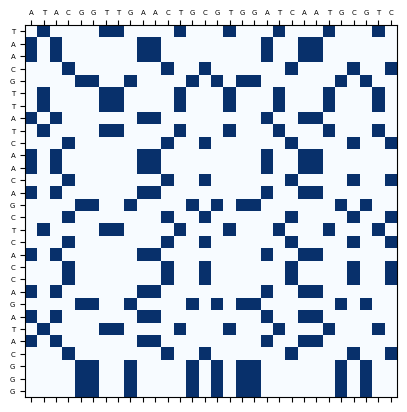

In [16]:
pair_align_map(del_ref, 30, True);

## <font size=5 color='#618CAC'>**looking for diagonal lines in the substitution matrix**</font>

A Micro-homology based deletion event (MH deletion) happens when there are two identical sequences (we called MH track)along the cutsite. During repairing, the repair machinaries will mistakenly adhere this two identical sequence. As a result, the sequence in the middle will be removed because of the mistaken adherision.  

Looking for MH track is thus very important. Within substitution matrices, it's quite a ease to find all possible MH tracks. This is because consecutive identical necleotides will be presented as diagonal line in the matrices. So our goal becomes finding all the long diagonal lines.

The function `construct_diagonal_map` incoporates building substitution matrix `pair_align_map` and filtering the matrixs with an identity matrix $I$ as the convolution filters `diag_conv_filter`. 

<Figure size 2560x1920 with 0 Axes>

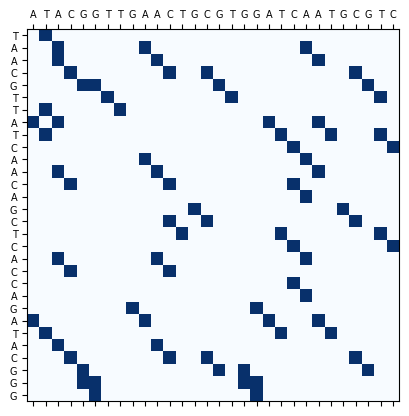

In [17]:
filtered_mat = construct_diagonal_map(del_ref, 30, True);

## <font size=5 color='#618CAC'> **extract MH feature from alignment map**  
    
<font size=4> Here we use 3 features to describe an event:  
- Starting site (ss)
- deletion length (dl)
- Maximal MH length (mml)

<font size=4>**Test** conv2d func from `scipy`.    
The test input is the bounded region, so it should return 5 if the func works  

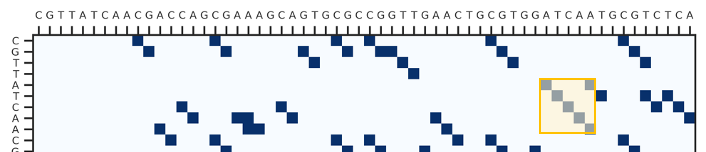


In [18]:
from models.alignmap import extract_features_from_map, extract_features_from_map, create_mmej_features

In [19]:
input_map = filtered_mat
detected_events = extract_features_from_map(input_map)

In [20]:
len(detected_events) # the total possible MH events detected

50

## Set up the trainer

# <font size=6 color='#ceac2d'>**3. Compiling event features**</font>

We use use the detected events to extract event features.
Firstly, the three important features:  
- Deletion length decay
- MH strength
- start site decay

In [21]:
def decay(x, k):
    y = 1 / (1+np.exp(x)**k)
    return y

We then incorporate the decay terms with other sequence features.

In [83]:
from inDecay import alignmap
from inDecay.alignmap import get_distal, get_proximal, compute_gc_ratio, del_ins_intercept, list_eval,get_ins_weight_bias

def ST_decayfeat_v2(label_df, refseq, cutsite, k1=0.5, k2=0.6, h=1.3):
    """
    Construct 18 features for each indel gen dataframe
    DEL : dl, ss, ss-decay, mml, proximal(left), aproximal(right), dl-decay, del_intcpt, n_events
    INS : insl, C, shift , full_complement ins, n_coevents
    Input
    ------------
    label_df : df by forecast indelgentarget , must contain columns [mh_length, identifier, loc, n_coevent]
    refseq : taraget sequence
    cutsite : pamsite -3
    k1 : ss decay param
    k2 : dl decay param
    h : MH strength scaler


    Return
    ------------
    x : np.ndarray, [df.shape, 18]
    """
    
    MML = label_df['mh_length'].values
    Idfs = label_df['Identifier'].values
    locs = label_df['loc'].values
    coevents = label_df['n_coevent'].values
    X2 = np.zeros((len(Idfs), 18))

    distal_mask = get_distal(label_df, cutsite)
    proximal_mask = get_proximal(label_df, cutsite)

    # prior knowledge  
    guide = refseq[cutsite-17:cutsite+3]
    guide_gc = compute_gc_ratio(guide)
    del_intcpt, ins_intcpt = del_ins_intercept(guide)

    for i,idf in enumerate(Idfs):
        indel_type, indel_size,  details, muts  = my_utils.tokFullIndel(idf)
        ss = details['L'] + details['C']

        # for i, locs in enumerate(label_df['loc'].values):
        loc_ls = locs[i]
        ss = np.max([ss_end[0] for ss_end in list_eval(loc_ls)]) - cutsite

        if indel_type == 'D':
            X2[i, 0] = indel_size
            X2[i, 1] = ss
            X2[i, 2] = decay(ss, k1)
            X2[i, 3] = MML[i]**h                   # max mm length
            X2[i, 4] = proximal_mask[i]            # proximal del, this is different from v1 !!
            X2[i, 5] = distal_mask[i]              # distal del, this is different from v1 !!
            X2[i, 6] = decay(indel_size, k2)
            X2[i, 7] = del_intcpt
            X2[i, 8] = coevents[i]

        elif indel_type == 'I':

            # one identifier may contain different inserted 
            inserts = [ss_end[-1] for ss_end in list_eval(loc_ls)]
            right_nt = refseq[cutsite : cutsite+indel_size]
            left_nt =  refseq[cutsite-indel_size:cutsite]

            X2[i, 9] = indel_size
            X2[i, 10] = details['C']
            X2[i, 11] = (ss + indel_size) == 0 
            X2[i, 12] = indel_size == details['C']
            X2[i, 13] = ins_intcpt
            X2[i, 14] = coevents[i]
            X2[i, 15] = 1/len(inserts)*int(right_nt in inserts)
            X2[i, 16] = 1/len(inserts)*int(left_nt in inserts)

        X2[i, 17] = guide_gc

    return X2

The above function returns 18 features in total. We can add interaction terms to increase the complecity.

In [113]:
import math

def interaction_transform(X, ndel, nins):
    """
    Data transformation
    """
    n_features = ndel + nins + math.comb(ndel,2) + math.comb(nins,2)
    n_total = X.shape[1]
    n_shared = n_total - ndel - nins
    interaction_del = []
    interaction_ins = []
    
    for i in range(0,ndel):
        for j in range(0,ndel):
            if i>=j:
                continue
            interaction_del.append(np.multiply(X[:,i],X[:,j]).reshape(-1,1))
    for i in range(ndel,ndel + nins):
        for j in range(ndel,ndel + nins): 
            if i>=j:
                continue
            interaction_ins.append(np.multiply(X[:,i],X[:,j]).reshape(-1,1))

    X_inter = np.concatenate([X] + interaction_del + interaction_ins, axis=1)
    
    if n_shared > 0:
        interaction_shared = []
        for i in range(ndel + nins, n_total):
            for j in range(ndel + nins):
                interaction_shared.append(np.multiply(X[:,i],X[:,j]).reshape(-1,1))

        X_inter = np.concatenate([X_inter]+ interaction_shared, axis=1)

    # assert X_inter.shape[1] == n_features 
    return X_inter

# <font size=6 color='#677e98'> **4. Construct Dataset and Dataloader**




We then build Pytorch Dataset, which is used to feed data to the model.

In [61]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

For a given OligoID, the `ST_dataset` will fetch the guide-RNA and the target sequence, extract sequence features and finally gather data in batch.

In [66]:
def get_reference():
    """
    get annotaion of the guides
    each value is a list of [Guide, refseq, pamsite, Strand]
    """
    reference_path = os.path.join(data_dir, 'SelfTarget_NewScaffold.fasta')
    
    reference =list(SeqIO.parse(reference_path,'fasta'))
    # dict : oligo -> list    
    ref_info_lookup = {}
    for SeqRecord in reference:
        OligoID, Guide = SeqRecord.id.split("_")
        _, pamsite, Strand = SeqRecord.description.split(" ")
        pamsite = int(pamsite)
        refseq = SeqRecord.seq.__str__()
        
        ref_info_lookup[OligoID] = [Guide, refseq, pamsite, Strand]
    return ref_info_lookup

In [85]:
def read_data(OligoID, processed_df, experiments):
    """Read the precompute features according to the OligoID"""
    # read features
    Guide, refseq, pamsite, Strand = ref_lookup[OligoID]

    idfgen_file = os.path.join(data_dir, 'Indelgen_result', f"{OligoID}_{Guide}_genindels.txt")
    idfgen = pd.read_table(idfgen_file, skiprows=1, names=['Identifier', 'n_coevent', 'loc'])

    def merging(OligoID,idfgen=idfgen):
        
        oligo_df = processed_df.query("`OligoID` == @OligoID")
        label_df = idfgen.merge(oligo_df[['OligoID','Identifier', 'Count']], 
                        left_on=['Identifier'], right_on=['Identifier'], suffixes=['', '_filled'], how='left') # type: ignore 
        label_df.fillna(0, inplace=True) # make indels that are not capture with count=0

        return label_df
    
    label_df = merging(OligoID)

    total_sum = label_df['Count'].sum()
    label_df['Frac Sample Reads'] = label_df['Count']/total_sum
    return label_df

Finally, with the `ST_dataset`, we can wrap the data reading, event detection, feature extraction and transformation all together.

In [92]:
from inDecay.reader import label_mh

In [114]:
class ST_dataset(Dataset):
    def __init__(self, Oligos, processed_df, experiments, read_data_fn, feat_ext_fn, 
                 transformation=lambda x: x, padding=False, normalize=True):
        """
        SelfTargeting dataset
        reading in the data for each indels, extract the features for each indels
        
        Arguments
        --------------
        Oligos: list of OligoIDs
        processed_df: pd.DataFrame object
        experiments: string
        read_data_fn: callable, how to get the indel details of a oligo
        feat_ext_fn: callable, how to get features from the read_data output
        transformation: callable, transformation function
        padding: bool, default False.
        
        Return
        --------------
        """
        self.Oligos = Oligos
        self.experiments = experiments
        self.processed_df = processed_df
        self.padding = padding
        self.Identifiers = {}
        self.transformation = transformation
        self.ins_wb = get_ins_weight_bias()
        self.feat_ext_fn = feat_ext_fn
        self.read_data_fn = read_data_fn
        self.label_col = 'Frac Sample Reads' if normalize else 'Count'

        if experiments == 'Sanger':
            self.ref_lookup = processed_df
        else:
            self.ref_lookup = get_reference()

    def __len__(self):
        return len(self.Oligos)
    
    
    def __getitem__(self,i):
        oligo = self.Oligos[i]
        Guide, refseq, pamsite, Strand = self.ref_lookup[oligo]
        cutsite = int(pamsite) - 3 

        assert Strand == 'FORWARD'

        label_df = self.read_data_fn(oligo, self.processed_df, self.experiments)
        # x = label_df[feature_columns].values

        mh_mask, label_df = label_mh(refseq, cutsite, label_df)

        x2 = self.feat_ext_fn(label_df, refseq, cutsite)
        x2 = self.transformation(x2)

        y = label_df[self.label_col].values

        # self.Identifiers[self.Oligos[i]] = label_df['Identifier']

        return x2.astype("float32"), y.astype("float32")

# <font size=6 color='#a698a1'>**5. Minimum inDecay model**</font>

When the data and features are ready, we can build an neural network to map event feature to the event frequency. As the weight-lifting is done by feature extraction, we only need simple model even like linear regression.

In [94]:
import torch
from torch import nn
import pytorch_lightning as pl

In [51]:
torch.cuda.is_available()

True

## pytorch lightning version

In [139]:
import torch.nn.functional as F

class inDecay(pl.LightningModule):
    """
    The base pl model that takes in features and then predict the probabity
    """

    def __init__(self, lr = 3e-4, n_features = 99):
        super().__init__()
        self.save_hyperparameters()

        self.lr = lr
        self.regressor = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.Mish(),                        # activation function
            nn.Linear(64, 1))


    def configure_optimizers(self):
        
        optimizer = torch.optim.Adam(
            self.parameters(), lr=self.lr)

        return optimizer

    def forward(self, train_batch):
        x,y  = train_batch 
        Out = self.regressor(x) # [b, N_indel, 99] -> [b, N_indel,1]
        y_pred = torch.softmax(Out.squeeze(2), dim=1)
        return y_pred, y    

    def compute_Loss(self, out, y):
        """
        NLL loss 
        """
        # TODO: weight case by total count
        #  = 200 for > 200 or S
        cre = -1* torch.multiply(torch.log(out+1e-5), y).sum(dim=1).mean()
        return cre

    def training_step(self, train_batch, batch_idx):

        # forward
        p_pred, y = self.forward(train_batch)
        loss = self.compute_Loss(p_pred, y)

        # compute all kinds of loss and metrices
        if torch.any(y.sum(1) != 1):
            y = y / y.sum(dim=1, keepdim=True)
        
        mse = F.mse_loss(p_pred, y,)
        
        # logging
        self.log('train_loss', loss, sync_dist=True)
        self.log('train_mse', mse, sync_dist=True)
        
        return loss

    def validation_step(self, val_batch, batch_idx):

        # forward
        p_pred, y = self.forward(val_batch)
        loss = self.compute_Loss(p_pred, y)

        # compute all kinds of loss and metrices
        if torch.any(y.sum(1) != 1):
            y = y / y.sum(dim=1, keepdim=True)
        
        mse = F.mse_loss(p_pred, y,)
        
        # logging
        self.log('val_loss', loss, sync_dist=True)
        self.log('val_mse', mse, sync_dist=True)
        
        return loss

    def predict_step(self, batch, batch_idx):
        p_pred, y = self.forward(batch)
        return p_pred

# <font size=6 color='#a698a1'> **6. Start training!**

In [119]:
# model params
k1 = 0.5 
k2 = 0.6
h = 1.3

# number of features for different types of event
ndel = 9
nins = 8
nshare = 1

In [120]:
# pass in the parameters
transform = lambda x: interaction_transform(x, ndel, nins)
feature_extraction_fn = lambda label_df, refseq, cutsite : ST_decayfeat_v2(label_df, refseq, cutsite, k1, k2, h)

# a partial function 
dataset_fn = lambda Oligos : ST_dataset(Oligos,processed_df, "K562_LV7A",  
                    read_data_fn = read_data,
                      transformation=transform,
                      feat_ext_fn = feature_extraction_fn,
                      normalize=True)

## Instanize the dataset and dataloader

In [169]:
# instanize dataset
Train_DS = dataset_fn(Train_Oligos)
Val_DS = dataset_fn(Val_Oligos)
Test_DS = dataset_fn(Test_Oligos)

# instanize dataloader , change num_workder according to the availble cpu cores
Train_DL = DataLoader(Train_DS, shuffle=True, batch_size=1, num_workers=8)
Val_DL = DataLoader(Val_DS, shuffle=False, batch_size=1, num_workers=8)
Test_DL = DataLoader(Test_DS, shuffle=False, batch_size=1, num_workers=8)

## Initialize the model (class -> real instance)

In [140]:
# the input of inDecay model is just the feature dimension, here feature dimension is determined by:
#  summing up deletion features, insertion features, shared features and their interaction terms
n_features = ndel + nins + nshare + math.comb(ndel,2) + math.comb(nins,2) + nshare*(ndel+nins)
model = inDecay(n_features=n_features, lr=3e-4)

device = 'gpu' if torch.cuda.is_available() else 'cpu'

## Set up the trainer

In [78]:
from pytorch_lightning import callbacks

In [171]:
trainer = pl.Trainer(
        auto_lr_find=True,
        accelerator='gpu',
        devices = [0],
        max_epochs=10,  # 10 for demostration, change the max epoch if you want better performance !!!
        callbacks=[
            callbacks.ModelCheckpoint(filename='{epoch}-{val_cre:.8f}',
                                              monitor="val_loss", mode="min", save_top_k=2),
            callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=20),])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [ ]:
model.train()
trainer.fit(model, Train_DL, val_dataloaders=Val_DL)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type       | Params
-----------------------------------------
0 | regressor | Sequential | 6.5 K 
-----------------------------------------
6.5 K     Trainable params
0         Non-trainable params
6.5 K     Total params
0.026     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

### now! predict the result for testset with trained model 

In [ ]:
model = inDecay.load_from_checkpoint("best_model.ckpt")

In [ ]:
predict_y = trainer.predict(model, Test_DL)